In [1]:
import pandas as pd
import os
import sys
import numpy as np
sys.path.append(os.path.abspath('..')) 
# Ajustar paths a tu nueva estructura
from features.external_features import add_vix_features
from features.feature_engineering import TechnicalFeatureEngineer
from sklearn.metrics import accuracy_score
from core.backtest_engine import WalkForwardBacktester
from core.experiment_tracker import QuantTracker
from validation.permutation_test import TargetShuffler
from validation.shap_diagnostics import ShapExplainer
from validation.generalization import TickerLeaveOneOut
from core.portfolio_metrics import PortfolioEvaluator
from core.optuna_tuner import QuantHyperTuner
from features.feature_selector import QuantFeatureSelector

tickers = ["SPY", "QQQ", "DIA", "GLD", "TLT", 'IWM']
dfs = []

for ticker in tickers:
    path = f"../data/raw/{ticker.lower()}_historical.parquet"
    if not os.path.exists(path):
        continue
        
    df_raw = pd.read_parquet(path)
    df_raw = add_vix_features(df_raw) 
    
    # Agregamos la columna antes de consolidar, para que el panel sepa quién es quién
    df_raw['ticker'] = ticker.upper()
    dfs.append(df_raw)

# 2. Consolidamos el panel crudo completo y ordenamos cronológicamente
df_panel_raw = pd.concat(dfs).sort_index()
df_panel_raw['ticker'] = df_panel_raw['ticker'].astype('category')

# 3. Aplicamos el Feature Engineering al bloque entero (Garantiza el cruce con SPY)
feature_maker = TechnicalFeatureEngineer()
df_panel = feature_maker.transform(df_panel_raw)

/home/daleffe/miniconda3/envs/genai_lab/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Descargando ^VIX...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Descargando ^VIX...
Descargando ^VIX...
Descargando ^VIX...
Descargando ^VIX...
Descargando ^VIX...


backtester_args = {
    'dias_entrenamiento': 500,
    'dias_paso': 20,
    'dias_embargo': 5
}

tuner = QuantHyperTuner(df_panel, backtester_args)

mejores_params = tuner.optimize(n_trials=100)

In [2]:
lgbm_params = {
    "objective": "multiclass",
    "num_class": 3,
    "learning_rate": 0.01941200712090007,
    "max_depth": 6,
    'n_estimators': 100,
    'num_leaves': 14,
    "random_state": 42,
    'min_child_samples': 161,
    "class_weight": {-1: 1.706516680936239, 0: 0.8, 1: 1.459406484913147},
    "verbose": -1,
    'reg_alpha': 0.001115771193064251,
    'reg_lambda': 0.0018137275679818334
}
umbral_compra=0.44176461620471413
umbral_venta=0.5964878382473806
q_high = 0.6053091352643017
q_low = 0.3985880507929194

In [3]:
backtester = WalkForwardBacktester(dias_entrenamiento=500, dias_paso=20, dias_embargo=5, q_high=q_high, q_low=q_low)  
df_res_real, last_model = backtester.run(df_panel, lgbm_params, umbral_compra=umbral_compra, umbral_venta=umbral_venta)
acc_real = accuracy_score(df_res_real['y_true'], df_res_real['y_pred'])

Iniciando Walk-Forward con Embargo de 5 días...
Backtest finalizado. 1806 operaciones simuladas.


In [7]:
CORRER_SHUFFLE_TEST = True
resultados_shuffle = True
CORRER_LOO_TEST = True
resultados_loo = True

In [8]:
if CORRER_SHUFFLE_TEST:
    shuffler = TargetShuffler(backtester_instance=backtester, iteraciones=3)
    resultados_shuffle = shuffler.run(df_panel, lgbm_params, real_accuracy=acc_real)
if CORRER_LOO_TEST:
    loo_validator = TickerLeaveOneOut(backtester_instance=backtester)
    resultados_loo = loo_validator.run(df_panel, lgbm_params)


--- INICIANDO TARGET SHUFFLING TEST (3 Iteraciones) ---
Corriendo Permutación 1/3...
Iniciando Walk-Forward con Embargo de 5 días...
Backtest finalizado. 1806 operaciones simuladas.
Corriendo Permutación 2/3...
Iniciando Walk-Forward con Embargo de 5 días...
Backtest finalizado. 1806 operaciones simuladas.
Corriendo Permutación 3/3...
Iniciando Walk-Forward con Embargo de 5 días...
Backtest finalizado. 1806 operaciones simuladas.
Accuracy Real: 0.2829 | Azar: 0.2553 | P-Value: 0.0000

--- INICIANDO TEST DE GENERALIZACIÓN (TICKER LEAVE-ONE-OUT) ---
Tickers disponibles: ['IWM', 'QQQ', 'DIA', 'GLD', 'SPY', 'TLT']

>> Dejando afuera: IWM
Accuracy prediciendo IWM sin haberlo visto nunca: 0.4167

>> Dejando afuera: QQQ
Accuracy prediciendo QQQ sin haberlo visto nunca: 0.3367

>> Dejando afuera: DIA
Accuracy prediciendo DIA sin haberlo visto nunca: 0.3233

>> Dejando afuera: GLD
Accuracy prediciendo GLD sin haberlo visto nunca: 0.3333

>> Dejando afuera: SPY
Accuracy prediciendo SPY sin habe

In [9]:
evaluator = PortfolioEvaluator()
metricas_fin = evaluator.calculate_metrics(df_res_real)
print("\n--- RESULTADOS FINANCIEROS REALES (OOS) ---")
print(f"Retorno Mercado (Equiponderado): {metricas_fin['Total_Return_Market']*100:.2f}%")
print(f"Retorno Estrategia:              {metricas_fin['Total_Return_Strat']*100:.2f}%")
print(f"Maximum Drawdown:                {metricas_fin['Max_Drawdown']*100:.2f}%")
print(f"Sharpe Ratio Anualizado:         {metricas_fin['Sharpe_Ratio']:.2f}")


--- RESULTADOS FINANCIEROS REALES (OOS) ---
Retorno Mercado (Equiponderado): 25.20%
Retorno Estrategia:              13.57%
Maximum Drawdown:                -3.60%
Sharpe Ratio Anualizado:         2.05



--- GENERANDO DIAGNÓSTICOS SHAP ---
Diagnósticos SHAP calculados con éxito.

Top 5 Variables (SHAP Mean Impact):
       feature  shap_mean_impact
0   vix_return          0.078273
1     accel_1d          0.042537
2       rsi_21          0.038246
3   sombra_inf          0.034696
4  cuerpo_vela          0.026316


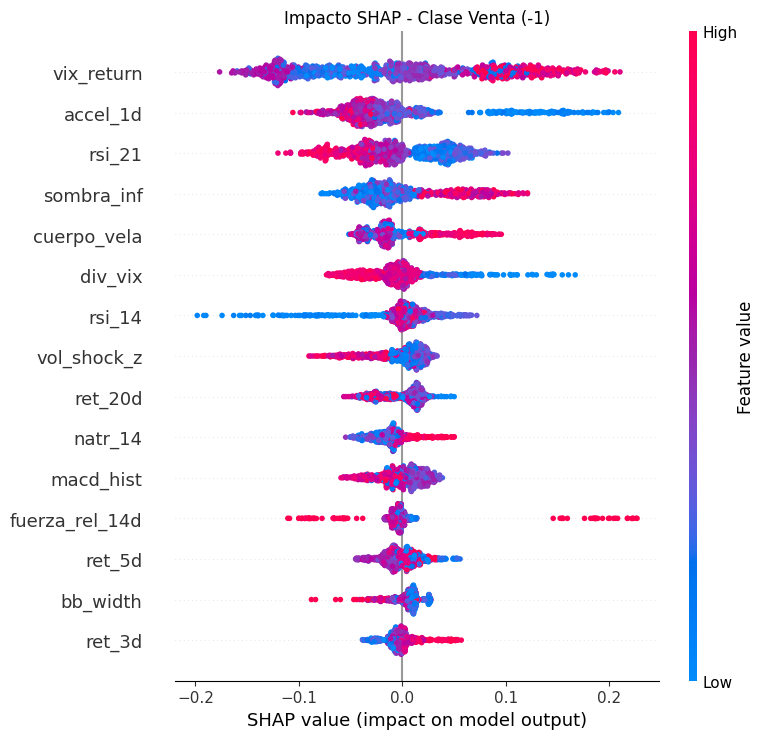

In [10]:
explainer = ShapExplainer()
df_shap, fig_shap = explainer.generate_diagnostics(last_model, df_panel)
print("\nTop 5 Variables (SHAP Mean Impact):")
print(df_shap.head(5))

In [11]:
tracker = QuantTracker(experiment_name="MultiTicker_WalkForward")
tracker.log_walk_forward_run(
    run_name="Feature Engineering",
    model_params=lgbm_params,
    y_true=df_res_real['y_true'].values,
    y_pred=df_res_real['y_pred'].values,
    dias_train=500,
    dias_paso=20,
    final_model=last_model,
    permutation_metrics=resultados_shuffle,
    shap_fig=fig_shap,   
    shap_df=df_shap,
    financial_metrics=metricas_fin,
    loo_metrics=resultados_loo,
    q_high = backtester.q_high,
    q_low=backtester.q_low,
    umbral_venta = umbral_venta,
    umbral_compra = umbral_compra
)

Run 'Feature Engineering' logueado a MLflow (Finanzas + Diagnósticos completos).
🏃 View run Feature Engineering at: http://localhost:5000/#/experiments/5/runs/23cae5271c514bf9a146c18e37544e12
🧪 View experiment at: http://localhost:5000/#/experiments/5


In [24]:
df_panel_raw

,open,high,low,close,volume,vix_close,vix_return,ticker
date,,,,,,,,
2020-01-02,295.672813,296.906540,294.749797,296.888245,59151200,12.47,NaN,SPY
2020-01-02,113.118904,113.730854,113.019674,113.300835,11034100,12.47,NaN,TLT
2020-01-02,143.860001,144.210007,143.399994,143.949997,7733800,12.47,NaN,GLD
2020-01-02,255.412228,257.365005,255.153634,257.356079,3865500,12.47,NaN,DIA
2020-01-02,206.621380,208.317535,206.216620,208.317535,30969400,12.47,NaN,QQQ
...,...,...,...,...,...,...,...,...
2025-12-31,398.600006,400.130005,395.589996,396.309998,10194700,14.95,0.042356,GLD
2025-12-31,618.869679,619.179286,613.276695,613.536377,40746500,14.95,0.042356,QQQ
2025-12-31,685.268559,685.487930,679.853355,680.062744,74144800,14.95,0.042356,SPY
